In [15]:
import pandas as pd
import plotly.express as px
from IPython.display import display, Image
from pathlib import Path

STATIC_RENDERING = True


force = False
anonymizer = True

root_dir = Path.cwd().parent.parent


def anondir(path: Path, prefix=root_dir) -> Path:
    """Anonymize a directory path by replacing user-specific parts with <root>."""
    if not anonymizer:
        return path
    path_str = str(path).replace(str(prefix), "<living-park>")
    return Path(path_str)


print(f"Running in root dir: {anondir(root_dir)}")

input_dir = root_dir / "data" / "dice"
assert input_dir.exists(), f"Input directory does not exist: {anondir(input_dir)}"
print(f"Input directory: {anondir(input_dir)}")

output_dir = root_dir / "results" / "dice"
output_dir.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {anondir(output_dir)}")

figures_dir = output_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)
print(f"Figures directory: {anondir(figures_dir)}")

Running in root dir: <living-park>
Input directory: <living-park>/data/dice
Output directory: <living-park>/results/dice
Figures directory: <living-park>/results/dice/figures


In [16]:
def save_figure(fig, filename, height=600, width=1400, scale=2, formats=None):
    """
    Save and display a plotly figure in multiple formats.

    Parameters
    ----------
    fig : plotly.graph_objects.Figure
        The plotly figure to save and display
    filename : str or Path
        The base filename (without extension) to save the figure to
    formats : list of str, optional
        List of formats to save ('html', 'pdf', 'png', 'svg')
        If None, only displays the figure

    Notes
    -----
    This function displays the figure and saves it in specified formats.
    For paper-quality figures, recommended formats are ['pdf', 'svg', 'png'].
    """
    # Always display the figure
    display(fig)

    # Save in specified formats
    if formats:
        filename = Path(filename)
        filename_anon = anondir(filename)

        # Ensure parent directory exists
        filename.parent.mkdir(parents=True, exist_ok=True)

        for fmt in formats:
            try:
                if fmt == "html":
                    fig.write_html(f"{filename}.html")
                    print(f"Saved: {filename_anon}.html")
                elif fmt == "pdf":
                    fig.write_image(
                        f"{filename}.pdf",
                        format="pdf",
                        width=width,
                        height=height,
                        scale=scale,
                    )
                    print(f"Saved: {filename_anon}.pdf")
                elif fmt == "png":
                    fig.write_image(
                        f"{filename}.png",
                        format="png",
                        width=width,
                        height=height,
                        scale=scale,
                    )
                    print(f"Saved: {filename_anon}.png")
                elif fmt == "svg":
                    fig.write_image(
                        f"{filename}.svg",
                        format="svg",
                        width=width,
                        height=height,
                        scale=scale,
                    )
                    print(f"Saved: {filename_anon}.svg")
                else:
                    print(f"Warning: Unsupported format '{fmt}' skipped")
            except Exception as e:
                print(f"Error saving {fmt} format: {e}")


def create_figure_metadata(fig, title, description, analysis_params):
    """
    Create metadata for a figure to ensure reproducibility.

    Parameters
    ----------
    fig : plotly.graph_objects.Figure
        The figure object
    title : str
        Figure title
    description : str
        Detailed description of what the figure shows
    analysis_params : dict
        Parameters used in the analysis

    Returns
    -------
    dict
        Metadata dictionary
    """
    return {
        "title": title,
        "description": description,
        "analysis_parameters": analysis_params,
        "figure_type": type(fig).__name__,
        "creation_timestamp": pd.Timestamp.now().isoformat(),
        "data_shape": getattr(fig, "data", [{}])[0].get("x", []),
        "layout_template": fig.layout.template.layout if fig.layout.template else None,
    }


In [17]:
df = pd.read_csv(input_dir / "dice_within_subjects.csv")
df.rename(columns={"iteration": "Subject"}, inplace=True)

labels = pd.read_csv(
    input_dir / "FS-LUT.txt",
    comment="#",
    sep=r"\s+",
    header=None,
    names=["No.", "Label", "R", "G", "B", "A"],
)

# Map label numbers to label names
label_map = dict(zip(labels["No."], labels["Label"]))
df["Label"] = df["label"].map(label_map)
df = df.drop(columns=["label"]).rename(columns={"dice": "Dice"})
df = df.dropna(subset=["Label"])
df = df.sort_values(by=["Label", "Subject"], ascending=[True, False])

ROI = df["Label"].unique()
Left_ROI = [roi for roi in ROI if "Left" in roi or "lh" in roi]
Right_ROI = [roi for roi in ROI if "Right" in roi or "rh" in roi]
Non_lateralized_ROI = [
    roi for roi in ROI if roi not in Left_ROI and roi not in Right_ROI
]

df["Hemisphere"] = df["Label"].apply(
    lambda x: (
        "Left" if x in Left_ROI else "Right" if x in Right_ROI else "Non-lateralized"
    )
)


def clean_labels(label):
    return (
        label.replace("Left-", "")
        .replace("Right-", "")
        .replace("wm-lh-S", "")
        .replace("wm-rh-S", "")
        .replace("lh-", "")
        .replace("rh-", "")
        .replace("ctx-", "")
    )


df["Label"] = df["Label"].apply(clean_labels)
df = df[df["Dice"] > 0]

In [18]:
cortical_regions = [
    "bankssts",
    "caudalanteriorcingulate",
    "caudalmiddlefrontal",
    "cuneus",
    "entorhinal",
    "fusiform",
    "inferiorparietal",
    "inferiortemporal",
    "isthmuscingulate",
    "lateraloccipital",
    "lateralorbitofrontal",
    "lingual",
    "medialorbitofrontal",
    "middletemporal",
    "parahippocampal",
    "paracentral",
    "parsopercularis",
    "parsorbitalis",
    "parstriangularis",
    "pericalcarine",
    "postcentral",
    "posteriorcingulate",
    "precentral",
    "precuneus",
    "rostralanteriorcingulate",
    "rostralmiddlefrontal",
    "superiorfrontal",
    "superiorparietal",
    "superiortemporal",
    "supramarginal",
    "frontalpole",
    "temporalpole",
    "transversetemporal",
    "insula",
]

subcortical_regions = [
    "Thalamus",
    "Caudate",
    "Putamen",
    "Pallidum",
    "Hippocampus",
    "Amygdala",
    "Accumbens-area",
]

In [19]:
# print average dice across all labels
print("Average Dice across all cortical labels:")
df_dice = df[df.Label.isin(cortical_regions)]
avg_dice = df_dice["Dice"].mean()
std_dice = df_dice["Dice"].std()
min_dice = df_dice["Dice"].min()
max_dice = df_dice["Dice"].max()
print(f"  - Average Dice: {avg_dice:.3f} ± {std_dice:.3f}")
print(f"  - Range Dice: {min_dice:.3f} - {max_dice:.3f}")

print("Average Dice across all subcortical labels:")
df_dice = df[df.Label.isin(subcortical_regions)]
avg_dice = df_dice["Dice"].mean()
std_dice = df_dice["Dice"].std()
min_dice = df_dice["Dice"].min()
max_dice = df_dice["Dice"].max()
print(f"  - Average Dice: {avg_dice:.3f} ± {std_dice:.3f}")
print(f"  - Range Dice: {min_dice:.3f} - {max_dice:.3f}")


Average Dice across all cortical labels:
  - Average Dice: 0.734 ± 0.132
  - Range Dice: 0.000 - 0.910
Average Dice across all subcortical labels:
  - Average Dice: 0.809 ± 0.086
  - Range Dice: 0.030 - 0.943


Saved: <living-park>/results/dice/figures/dice.png
Saved: <living-park>/results/dice/figures/dice.pdf
Figure saved to: <living-park>/results/dice/figures/dice


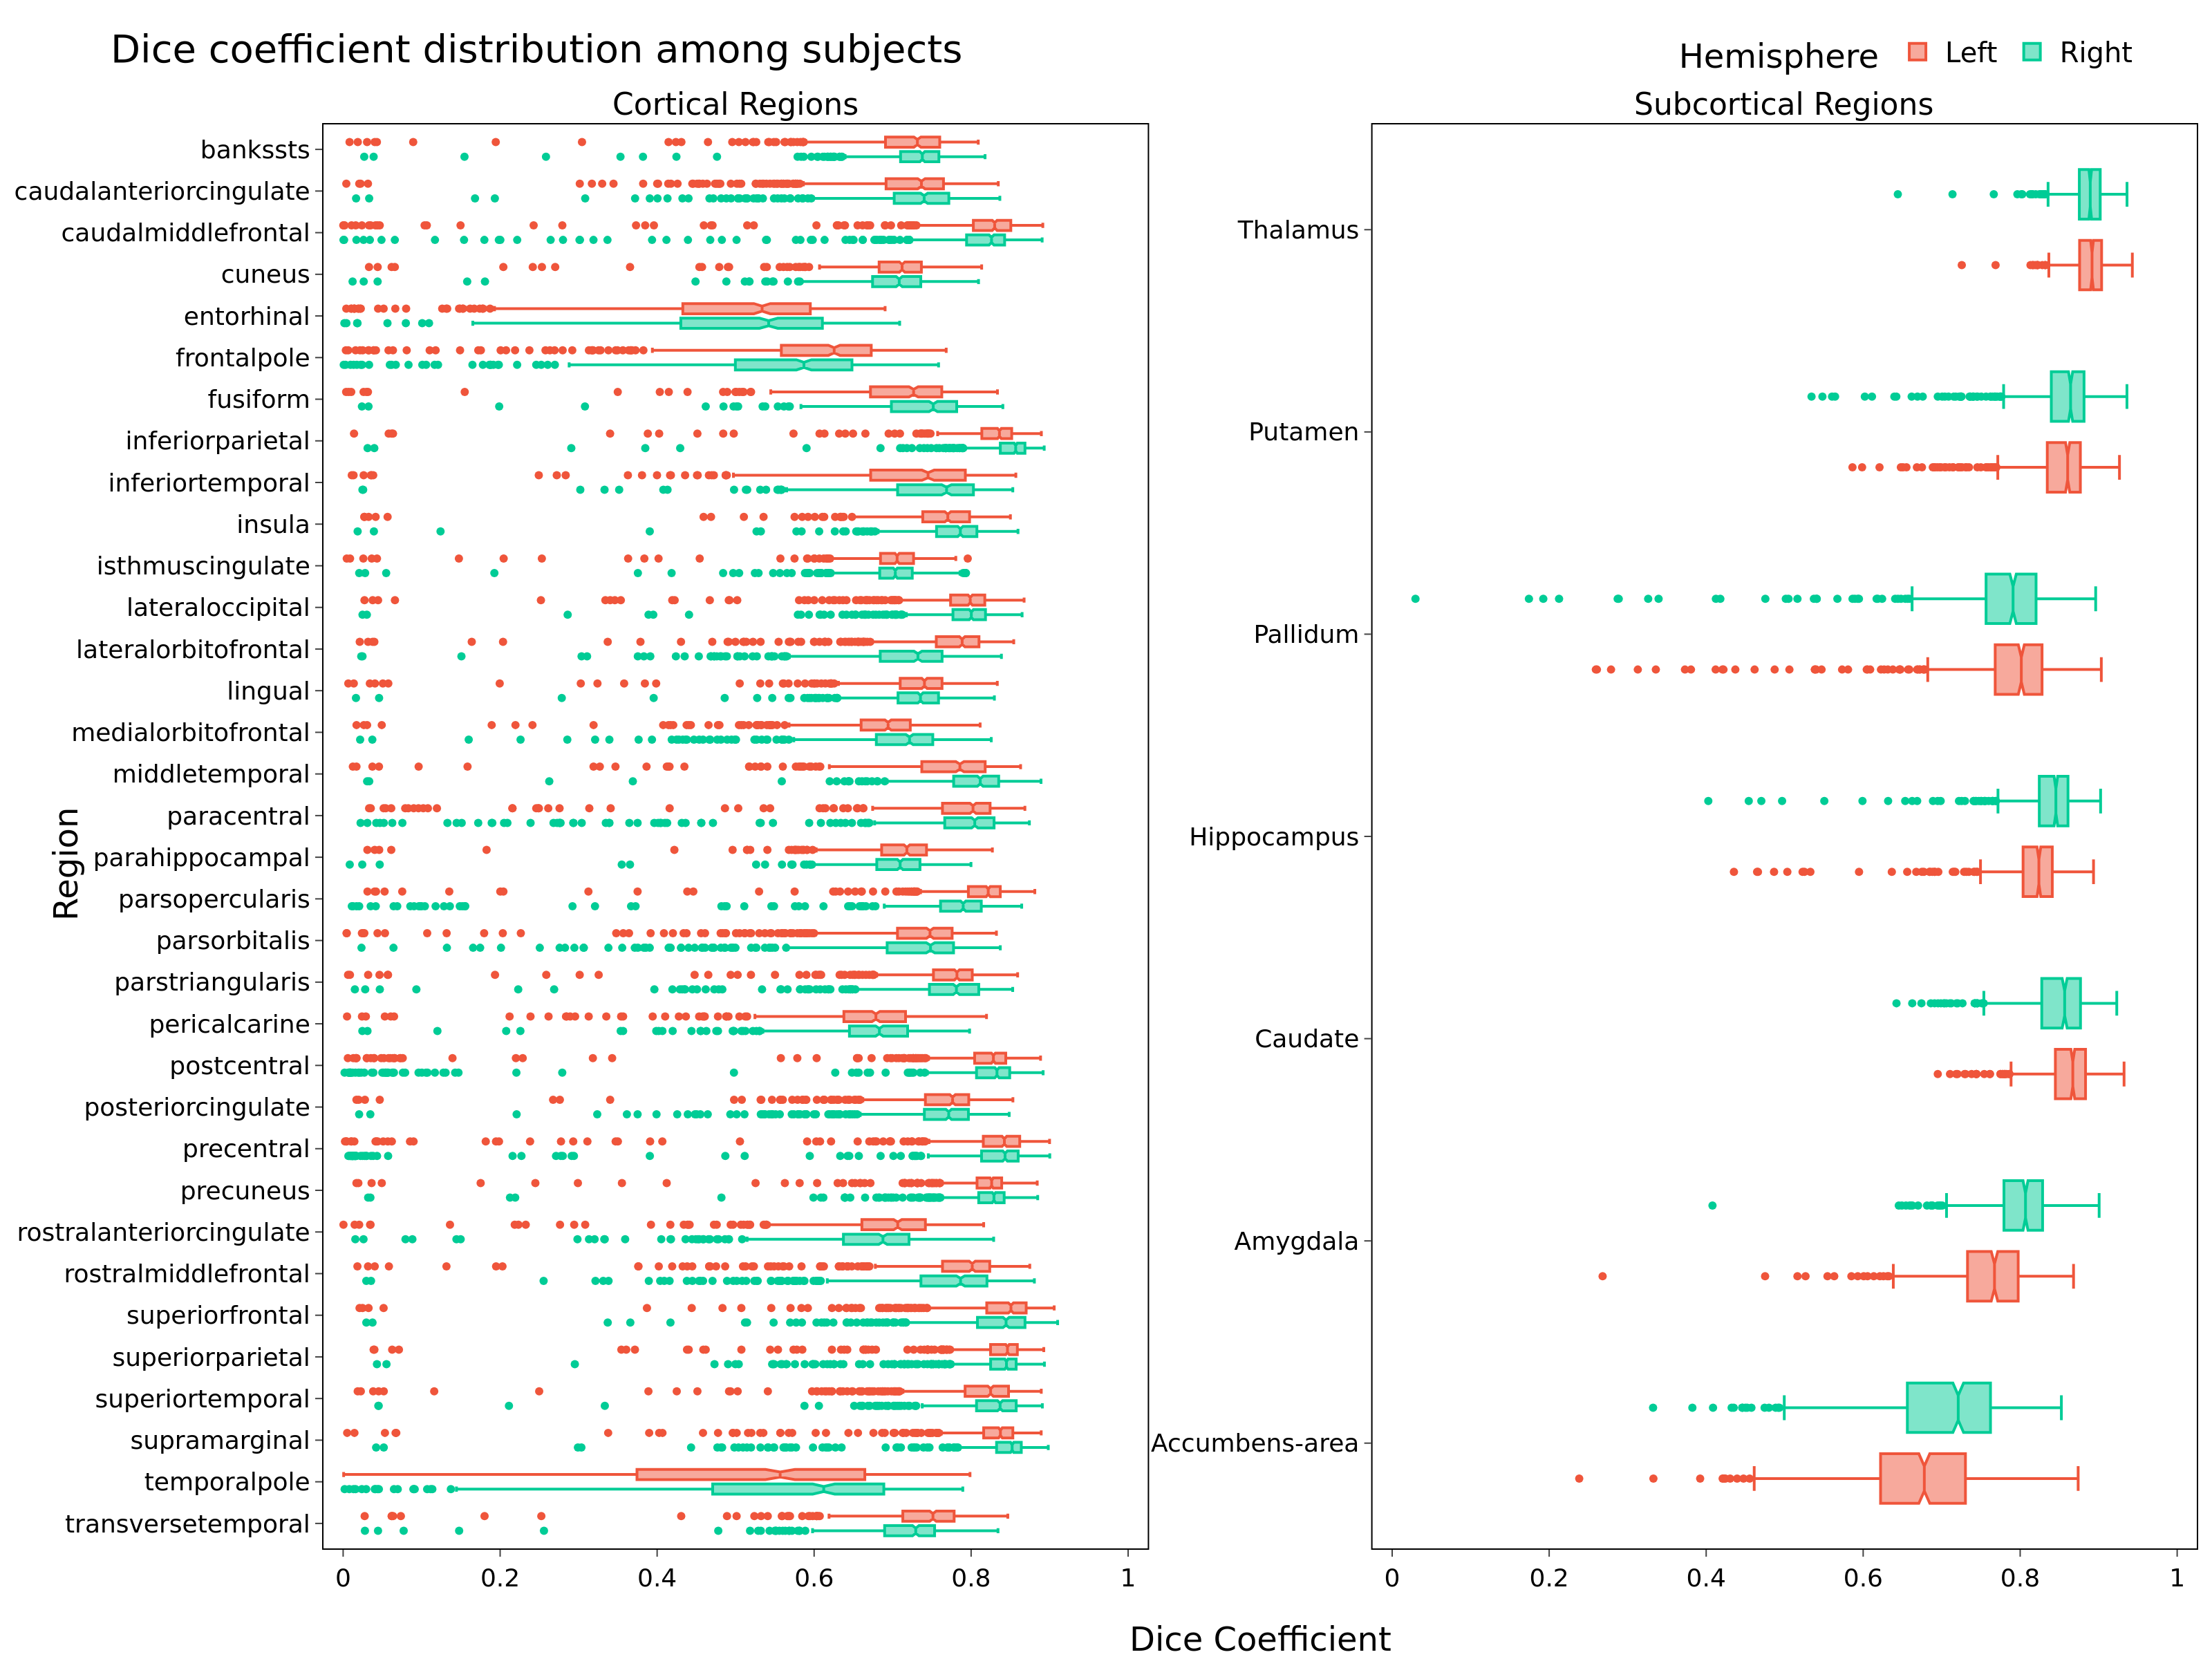

In [20]:
from plotly.subplots import make_subplots
import plotly.colors as pc

df["Label"] = df["Label"].str.replace("_", " ")


labels = df.Label.unique()
# remove the 'Unknown' and 'non-WM-hypointensities' labels
labels = labels[labels != "Unknown"]
labels = labels[labels != "non-WM-hypointensities"]
labels = labels[labels != "undetermined"]

# split labels into 2 groups to have 2 box plots on 2 columns
labels1 = cortical_regions
labels2 = subcortical_regions

df1 = df[df.Label.isin(labels1)]
df2 = df[df.Label.isin(labels2)]

fig = make_subplots(
    rows=1,
    cols=2,
    x_title="Dice Coefficient",
    y_title="Region",
    column_titles=["Cortical Regions", "Subcortical Regions"],
    horizontal_spacing=0.12,
)

colors = {
    "Left": pc.qualitative.Plotly[1],
    "Right": pc.qualitative.Plotly[2],
}

fig1 = px.box(
    df1,
    x="Dice",
    y="Label",
    title="Dice coefficient distribution among subejcts",
    color="Hemisphere",
    notched=True,
    orientation="h",
)

fig2 = px.box(
    df2,
    x="Dice",
    y="Label",
    title="Dice coefficient distribution among subejcts",
    color="Hemisphere",
    notched=True,
    orientation="h",
)

for data in fig1.data:
    # add y-shift to the box plot
    data.showlegend = False
    data.marker.color = colors[data.name]
    fig.add_trace(data, row=1, col=1)

for data in fig2.data:
    data.marker.color = colors[data.name]
    fig.add_trace(data, row=1, col=2)

fig.layout.annotations[-1].xshift = -150  # Adjust the x position of the title
fig.update_layout(
    title="Dice coefficient distribution among subjects",
    boxmode="group",
    legend=dict(
        title="Hemisphere",
        tracegroupgap=0,
        orientation="h",
        yanchor="top",
        y=1.07,
        xanchor="right",
        x=0.97,
    ),
    margin=dict(l=50, r=10, t=90, b=80),
    xaxis=dict(range=[-0.025, 1.025]),
    xaxis2=dict(range=[-0.025, 1.025]),
    font=dict(family="Helvetica, sans serif", color="black", size=20),
    paper_bgcolor="White",
    plot_bgcolor="White",
)

fig.update_xaxes(
    mirror=True, ticks="outside", showline=True, linewidth=1, linecolor="black"
)
fig.update_yaxes(
    mirror=True, ticks="outside", showline=True, linewidth=1, linecolor="black"
)

fig.update_annotations(
    font=dict(family="Helvetica, sans serif", color="black", size=22)
)
fig.update_xaxes(tickfont=dict(family="Helvetica, sans serif", color="black", size=18))
fig.update_yaxes(tickfont=dict(family="Helvetica, sans serif", color="black", size=18))
fig.update_layout(
    title_font=dict(family="Helvetica, sans serif", color="black", size=28), title_y=1
)

for annotation in fig.layout.annotations:
    if annotation.text == "Region":
        annotation.yshift = -20
        annotation.xshift = -170
        annotation.font.size = 24
    if annotation.text == "Dice Coefficient":
        annotation.yshift = -50
        annotation.font.size = 24

fig.update_yaxes(autorange="reversed", row=1, col=1)

fig.update_layout(
    width=1600, height=1200, title="Dice coefficient distribution among subjects"
)
filename = figures_dir / "dice"
save_figure(fig, filename, width=1600, height=1200, scale=2, formats=["png", "pdf"])
print(f"Figure saved to: {anondir(filename)}")
display(Image(filename.with_suffix(".png")))
